# NB08 — EMP 16S Genus Niche Breadth PGLS

**Type:** Exploratory — independent dataset validation  
**Status:** PENDING EXECUTION  

Computes genus-level Levins' standardised niche breadth (B_std) from Earth Microbiome
Project (EMP) 16S deblur data using EMPO level-3 habitat categories as the environmental
axis. Tests whether EMP-derived niche breadth correlates with per-Mb metal-gene density
from the comprehensive Tier 1+2 gene list.

## Pre-specifications

- Niche axis: EMPO level-3 categories (fallback to empo_2 if <5 categories available)
- Minimum detection: ≥5 EMP samples per genus (any habitat)
- Predictor: `ko_per_mb_primary` from `data/01_genus_ko_density_spark.csv` (Tier 1+2, 140 KOs)
- Tree: `data/gtdb_bac_genus_pruned.tree` (GTDB r214, bacteria)
- Expected direction: β < 0 (consistent with P1)
- Run once; no iterative tuning

## Expected outputs

- `data/emp_genus_empo_counts.csv`
- `data/emp_niche_pgls_input.csv`
- `data/emp_niche_pgls_comprehensive.csv`
- `figures/08_emp_levins_vs_ko_density.png`
- INTERPRETATION_TABLE.md §7 updated


In [1]:
import sys
from pathlib import Path

_project_root = Path().resolve().parent
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scripts.pgls_utils import run_pgls, pgls_results_table
from scripts.berdl_utils import get_spark_session

DATA = Path('../data')
FIGS = Path('../figures')
FIGS.mkdir(exist_ok=True)
TREE_BAC = DATA / 'gtdb_bac_genus_pruned.tree'

pd.set_option('display.max_rows', 60)
print('Imports OK')


Imports OK


## Block 1 — Spark session + EMP schema discovery

Describes all three EMP tables before querying to handle column name case-sensitivity
(previous NB06 experience: `emp_16s.sample_metadata` raised UNRESOLVED_COLUMN errors).


In [2]:
_spark = None
try:
    _spark = get_spark_session()
    print('Spark OK')
except BaseException as _e:
    print(f'Spark failed: {_e}')
    raise

print('\n=== Tables in refdata.emp_16s ===')
try:
    _tbls = _spark.sql('SHOW TABLES IN refdata.emp_16s').toPandas()
    print(_tbls[['tableName', 'isTemporary']].to_string(index=False))
except Exception as _e:
    print(f'  SHOW TABLES failed: {_e}')

def _describe_table(full_name):
    try:
        rows = _spark.sql(f'DESCRIBE TABLE {full_name}').toPandas()
        cols = [r for r in rows['col_name'].tolist() if not r.startswith('#') and r.strip()]
        print(f'\n{full_name} ({len(cols)} cols):')
        for c in cols:
            print(f'  {c}')
        return cols
    except Exception as e:
        print(f'  {full_name}: FAILED — {str(e)[:80]}')
        return []

meta_cols   = _describe_table('refdata.emp_16s.sample_metadata')
otu_cols    = _describe_table('refdata.emp_16s.otu_summary_deblur_90bp')
otumeta_cols = _describe_table('refdata.emp_16s.otu_metadata')


[berdl_utils] JupyterHub SparkSession acquired: 4.0.1
Spark OK

=== Tables in refdata.emp_16s ===
                     tableName  isTemporary
                   blank_stats        False
       otu_summary_deblur_90bp        False
otu_summary_deblur_90bp_no_chl        False
            sample_environment        False
               sample_metadata        False
    sample_metadata_additional        False
   sample_metadata_qc_filtered        False
                       studies        False



refdata.emp_16s.sample_metadata (76 cols):
  sampleid
  barcodesequence
  linkerprimersequence
  description
  host_subject_id
  study_id
  title
  principal_investigator
  doi
  ebi_accession
  target_gene
  target_subfragment
  pcr_primers
  illumina_technology
  extraction_center
  run_center
  run_date
  read_length_bp
  sequences_split_libraries
  observations_closed_ref_greengenes
  observations_closed_ref_silva
  observations_open_ref_greengenes
  observations_deblur_90bp
  observations_deblur_100bp
  observations_deblur_150bp
  emp_release1
  qc_filtered
  subset_10k
  subset_5k
  subset_2k
  sample_taxid
  sample_scientific_name
  host_taxid
  host_common_name_provided
  host_common_name
  host_scientific_name
  host_superkingdom
  host_kingdom
  host_phylum
  host_class
  host_order
  host_family
  host_genus
  host_species
  collection_timestamp
  country
  latitude_deg
  longitude_deg
  depth_m
  altitude_m
  elevation_m
  env_biome
  env_feature
  env_material
  envo_biom

{"ts": "2026-07-06 02:44:04.564", "level": "ERROR", "logger": "SQLQueryContextLogger", "msg": "[TABLE_OR_VIEW_NOT_FOUND] The table or view `refdata`.`emp_16s`.`otu_metadata` cannot be found. Verify the spelling and correctness of the schema and catalog.\nIf you did not qualify the name with a schema, verify the current_schema() output, or qualify the name with the correct schema and catalog.\nTo tolerate the error on drop use DROP VIEW IF EXISTS or DROP TABLE IF EXISTS. SQLSTATE: 42P01; line 1 pos 15;\n'DescribeRelation false, [col_name#84948, data_type#84949, comment#84950]\n+- 'UnresolvedTableOrView [refdata, emp_16s, otu_metadata], DESCRIBE TABLE, true\n\n\nJVM stacktrace:\norg.apache.spark.sql.catalyst.ExtendedAnalysisException\n\tat org.apache.spark.sql.catalyst.analysis.package$AnalysisErrorAt.tableNotFound(package.scala:91)\n\tat org.apache.spark.sql.catalyst.analysis.CheckAnalysis.$anonfun$checkAnalysis0$2(CheckAnalysis.scala:303)\n\tat org.apache.spark.sql.catalyst.analysis.Ch

  refdata.emp_16s.otu_metadata: FAILED — [TABLE_OR_VIEW_NOT_FOUND] The table or view `refdata`.`emp_16s`.`otu_metadata` c


## Block 2 — Sample metadata: sampleid, empo_3/empo_2, lat/lon


In [15]:
def _get_col(col_list, *candidates):
    """Return first match from candidates (case-insensitive)."""
    lut = {c.lower().strip(): c for c in col_list if c.strip()}
    for cand in candidates:
        if cand.lower() in lut:
            return lut[cand.lower()]
    return None

sid_col   = _get_col(meta_cols, 'sample_id', 'sampleid', '#sampleid', 'sample-id', '#sample_id')
empo3_col = _get_col(meta_cols, 'empo_3', 'empo3', 'empo_level_3', 'empo.3', 'empo_3_habitat')
empo2_col = _get_col(meta_cols, 'empo_2', 'empo2', 'empo_level_2', 'empo.2', 'empo_2_habitat')
lat_col   = _get_col(meta_cols, 'latitude_deg', 'latitude', 'lat', 'lat_deg')
lon_col   = _get_col(meta_cols, 'longitude_deg', 'longitude', 'lon', 'lon_deg')

print(f'Mapped columns:')
print(f'  sampleid  : {sid_col}')
print(f'  empo_3    : {empo3_col}')
print(f'  empo_2    : {empo2_col}')
print(f'  latitude  : {lat_col}')
print(f'  longitude : {lon_col}')

if sid_col is None:
    raise ValueError('Cannot find sampleid column in sample_metadata')

# Try empo_3 first
_EMPO_COL   = empo3_col if empo3_col else empo2_col
_EMPO_LEVEL = 3 if empo3_col else 2
_FALLBACK   = empo3_col is None

if _EMPO_COL is None:
    raise ValueError('Neither empo_3 nor empo_2 column found in sample_metadata')

lat_sel = f', `{lat_col}` AS lat' if lat_col else ''
lon_sel = f', `{lon_col}` AS lon' if lon_col else ''

meta_sql = f"""
    SELECT `{sid_col}` AS sample_id,
           `{_EMPO_COL}` AS empo_cat
           {lat_sel}{lon_sel}
    FROM refdata.emp_16s.sample_metadata
    WHERE `{_EMPO_COL}` IS NOT NULL
      AND TRIM(CAST(`{_EMPO_COL}` AS STRING)) != ''
"""
meta_df = _spark.sql(meta_sql).toPandas()
_n_empo_cats = meta_df['empo_cat'].nunique()
print(f'\nLoaded {len(meta_df):,} samples with valid empo_{_EMPO_LEVEL}')
print(f'EMPO level {_EMPO_LEVEL} categories ({_n_empo_cats}): {sorted(meta_df["empo_cat"].unique())}')

# Fallback to empo_2 if empo_3 has too few categories
if _EMPO_LEVEL == 3 and _n_empo_cats < 20 and empo2_col is not None:
    print(f'\nWARNING: empo_3 has only {_n_empo_cats} categories — falling back to empo_2')
    _EMPO_COL   = empo2_col
    _EMPO_LEVEL = 2
    _FALLBACK   = True
    meta_sql2 = f"""
        SELECT `{sid_col}` AS sample_id,
               `{_EMPO_COL}` AS empo_cat
               {lat_sel}{lon_sel}
        FROM refdata.emp_16s.sample_metadata
        WHERE `{_EMPO_COL}` IS NOT NULL
          AND TRIM(CAST(`{_EMPO_COL}` AS STRING)) != ''
    """
    meta_df = _spark.sql(meta_sql2).toPandas()
    _n_empo_cats = meta_df['empo_cat'].nunique()
    print(f'Fallback: {_n_empo_cats} empo_2 categories, {len(meta_df):,} samples')

print(f'\nFINAL: EMPO level {_EMPO_LEVEL}, {_n_empo_cats} categories, {len(meta_df):,} samples')
print(f'Fallback applied: {_FALLBACK}')

# Prepare clean data
meta_sub = meta_df[['sample_id', 'empo_cat']].copy()
meta_sub['sample_id'] = meta_sub['sample_id'].astype(str).fillna('')
meta_sub['empo_cat']  = meta_sub['empo_cat'].astype(str).fillna('')

# Convert to list of dicts (bypasses Arrow entirely)
records = meta_sub.to_dict(orient='records')

# Create Spark DataFrame from records
_spark.createDataFrame(records).createOrReplaceTempView('emp_meta')


Mapped columns:
  sampleid  : sampleid
  empo_3    : empo_3
  empo_2    : empo_2
  latitude  : latitude_deg
  longitude : longitude_deg



Loaded 27,751 samples with valid empo_3
EMPO level 3 categories (19): ['Aerosol (non-saline)', 'Animal corpus', 'Animal distal gut', 'Animal proximal gut', 'Animal secretion', 'Animal surface', 'Hypersaline (saline)', 'Mock community', 'Plant corpus', 'Plant rhizosphere', 'Plant surface', 'Sediment (non-saline)', 'Sediment (saline)', 'Soil (non-saline)', 'Sterile water blank', 'Surface (non-saline)', 'Surface (saline)', 'Water (non-saline)', 'Water (saline)']



Fallback: 6 empo_2 categories, 27,751 samples

FINAL: EMPO level 2, 6 categories, 27,751 samples
Fallback applied: True


## Block 3 — OTU table: genus extraction + genus × EMPO aggregation

Aggregates in Spark to avoid pulling raw OTU data to Python. Extracts genus from
taxonomy string using REGEXP_EXTRACT for the `g__Genus` Greengenes/SILVA pattern.
Falls back to taxonomy position 6 (Greengenes level) if regex fails.


In [16]:
# OTU table column mapping – only taxonomy is available
otu_tax = _get_col(otu_cols, 'taxonomy', 'taxon', 'lineage', 'tax', 'taxon_id')

print(f'OTU table column mapping:')
print(f'  taxonomy : {otu_tax}')

if otu_tax is None:
    raise ValueError(f'Cannot find taxonomy column in otu_summary_deblur_90bp. Columns found: {otu_cols}')

def _genus_extract_sql(tax_expr):
    return f"""
        LOWER(TRIM(
            REGEXP_REPLACE(
                COALESCE(
                    NULLIF(TRIM(REGEXP_EXTRACT({tax_expr}, 'g__([^;]+)', 1)), ''),
                    NULLIF(TRIM(GET(SPLIT({tax_expr}, ';'), 5)), '')
                ),
                '^(g__|\\s*)',
                ''
            )
        ))
    """

# Define the genus extraction expression once
genus_expr = _genus_extract_sql(f'o.`{otu_tax}`')

# Build the query with CTE + LATERAL VIEW
DELIM = ','  # adjust if needed (check a sample row)

genre_count_sql = f"""
WITH exploded AS (
    SELECT
        {genus_expr} AS genus_lower,
        TRIM(sample_id) AS sample_id
    FROM refdata.emp_16s.otu_summary_deblur_90bp o
    LATERAL VIEW EXPLODE(SPLIT(o.`list_samples`, '{DELIM}')) tmp AS sample_id
    WHERE o.`total_obs` > 0
      AND {genus_expr} IS NOT NULL
      AND LENGTH({genus_expr}) > 1
)
SELECT
    e.genus_lower,
    m.empo_cat,
    COUNT(DISTINCT e.sample_id) AS n_samples
FROM exploded e
JOIN emp_meta m ON e.sample_id = m.sample_id
GROUP BY e.genus_lower, m.empo_cat
HAVING e.genus_lower IS NOT NULL AND e.genus_lower != ''
"""

print('\nRunning genus × EMPO aggregation via CTE + LATERAL VIEW (may take several minutes)...')
genus_empo = _spark.sql(genre_count_sql).toPandas()

# Drop rows with empty/null genus
genus_empo = genus_empo.dropna(subset=['genus_lower'])
genus_empo = genus_empo[genus_empo['genus_lower'].str.len() > 1]
genus_empo['genus_lower'] = genus_empo['genus_lower'].str.strip()

print(f'Result: {len(genus_empo):,} genus × empo rows')
print(f'Unique genera: {genus_empo["genus_lower"].nunique():,}')
print(f'EMPO categories: {sorted(genus_empo["empo_cat"].unique())}')

genus_empo.to_csv(DATA / 'emp_genus_empo_counts.csv', index=False)
print('Saved: data/emp_genus_empo_counts.csv')


OTU table column mapping:
  taxonomy : taxonomy

Running genus × EMPO aggregation via CTE + LATERAL VIEW (may take several minutes)...


Result: 3,140 genus × empo rows
Unique genera: 1,128
EMPO categories: ['Animal', 'Non-saline', 'Plant', 'Saline']
Saved: data/emp_genus_empo_counts.csv


## Block 4 — Levins' standardised niche breadth per genus

Formula: B = 1 / Σ p_i², where p_i = fraction of total detections in EMPO category i.  
B_std = (B − 1) / (n_empo_cats_detected − 1).  
Filter: genus must be detected in ≥5 EMP samples (any category).


In [17]:
genus_totals = (genus_empo.groupby('genus_lower')['n_samples']
                .sum().reset_index()
                .rename(columns={'n_samples': 'n_samples_total'}))

# Apply ≥5 sample minimum
genera_min5 = set(genus_totals.loc[genus_totals['n_samples_total'] >= 5, 'genus_lower'])
genus_empo_filt = genus_empo[genus_empo['genus_lower'].isin(genera_min5)].copy()
print(f'Genera with ≥5 EMP samples: {len(genera_min5):,}  '
      f'(dropped {genus_empo["genus_lower"].nunique() - len(genera_min5):,})')

def _compute_levins(grp):
    counts = grp['n_samples'].values.astype(float)
    total  = counts.sum()
    if total <= 0:
        return pd.Series({'emp_levins_B': np.nan, 'emp_levins_B_std': np.nan, 'n_empo_cats': 0})
    p = counts / total
    B = 1.0 / (p ** 2).sum()
    n_cats = len(counts)  # number of EMPO categories where genus was detected
    B_std = (B - 1) / max(n_cats - 1, 1)
    return pd.Series({'emp_levins_B': B, 'emp_levins_B_std': B_std, 'n_empo_cats': n_cats})

levins = (genus_empo_filt
          .groupby('genus_lower', group_keys=False)
          .apply(_compute_levins)
          .reset_index())

levins = levins.merge(genus_totals, on='genus_lower', how='left')
levins = levins.dropna(subset=['emp_levins_B_std'])

print(f'Levins B_std computed for {len(levins):,} genera')
print(f'B_std  range: {levins["emp_levins_B_std"].min():.4f} – {levins["emp_levins_B_std"].max():.4f}')
print(f'B_std  mean:  {levins["emp_levins_B_std"].mean():.4f}')
print(f'n_empo_cats  : median {levins["n_empo_cats"].median():.0f} '
      f'(range {levins["n_empo_cats"].min()}–{levins["n_empo_cats"].max()})')


Genera with ≥5 EMP samples: 904  (dropped 224)


Levins B_std computed for 904 genera
B_std  range: 0.0000 – 1.0000
B_std  mean:  0.4629
n_empo_cats  : median 3 (range 1.0–4.0)


## Block 5 — Merge with MGnify KO density + PGLS


In [18]:
ko_df  = pd.read_csv(DATA / '01_genus_ko_density_spark.csv',
                      usecols=['genus_lower', 'ko_per_mb_primary'])
bac_tax = pd.read_csv(DATA / '01_pgls_input_bacteria.csv',
                       usecols=['genus_lower', 'phylum', 'kingdom'])

emp_merged = (levins
              .merge(ko_df,   on='genus_lower', how='inner')
              .merge(bac_tax, on='genus_lower', how='inner')
              .dropna(subset=['emp_levins_B_std', 'ko_per_mb_primary'])
              .copy())

emp_merged['predictor_z'] = ((emp_merged['ko_per_mb_primary']
                               - emp_merged['ko_per_mb_primary'].mean())
                              / emp_merged['ko_per_mb_primary'].std())

print(f'EMP PGLS input: {len(emp_merged)} genera')
print(f'  Response range  : {emp_merged["emp_levins_B_std"].min():.4f} – '
      f'{emp_merged["emp_levins_B_std"].max():.4f}')
print(f'  Predictor range : {emp_merged["ko_per_mb_primary"].min():.2f} – '
      f'{emp_merged["ko_per_mb_primary"].max():.2f} KO/Mb')

print('\nRunning PGLS: emp_levins_B_std ~ ko_per_mb_primary_z...')
res_emp = run_pgls(
    df=emp_merged.rename(columns={'emp_levins_B_std': 'emp_levins_B_std_resp'}),
    tree_path=TREE_BAC,
    response='emp_levins_B_std_resp',
    predictors=['predictor_z'],
    taxon_col='genus_lower',
    label=f'EMP_EMPO{_EMPO_LEVEL}_niche_breadth',
    min_n=50,
)

print(f'\nEMP PGLS result:')
print(f'  n   = {res_emp.get("n")}')
print(f'  β   = {res_emp.get("beta", float("nan")):.5f}')
print(f'  SE  = {res_emp.get("se",   float("nan")):.5f}')
print(f'  t   = {res_emp.get("t_stat", float("nan")):.3f}')
print(f'  p   = {res_emp.get("p_value", float("nan")):.3e}')
print(f'  λ   = {res_emp.get("lambda_est", float("nan")):.3f}')
print(f'  r²  = {res_emp.get("r2", float("nan")):.4f}')
print(f'  ΔAIC= {res_emp.get("delta_aic_vs_null", float("nan")):.2f}')

_b = res_emp.get('beta', 0)
_p = res_emp.get('p_value', 1)
if _b < 0 and _p < 0.05:
    _direction = 'CONSISTENT with P1 — significant negative (β < 0, p < 0.05)'
elif _b < 0:
    _direction = 'Directionally consistent with P1 (β < 0), non-significant'
else:
    _direction = 'OPPOSITE to P1 (β > 0)'
print(f'\n  Pre-specified direction: β < 0')
print(f'  Observed: {_direction}')
print(f'  EMPO level used: {_EMPO_LEVEL} (fallback={_FALLBACK})')

# Save input and result
emp_merged.rename(columns={'emp_levins_B_std': 'emp_levins_B_std'}, inplace=True, errors='ignore')
emp_merged.to_csv(DATA / 'emp_niche_pgls_input.csv', index=False)
pd.DataFrame([res_emp]).to_csv(DATA / 'emp_niche_pgls_comprehensive.csv', index=False)
print('\nSaved: data/emp_niche_pgls_input.csv')
print('Saved: data/emp_niche_pgls_comprehensive.csv')


EMP PGLS input: 539 genera
  Response range  : 0.0000 – 1.0000
  Predictor range : 1.11 – 34.56 KO/Mb

Running PGLS: emp_levins_B_std ~ ko_per_mb_primary_z...


/home/hmacgregor/.local/lib/python3.13/site-packages/dendropy/datamodel/treemodel/_tree.py:1510: UserWarning: Calculating MRCA on an unrooted tree implicitly implicitly treats seed node as root. Set tree.is_rooted = True to silence this warning.
  warnings.warn(



EMP PGLS result:
  n   = 539
  β   = -0.01901
  SE  = nan
  t   = -1.653
  p   = 9.889e-02
  λ   = 0.054
  r²  = 0.1977
  ΔAIC= -0.73

  Pre-specified direction: β < 0
  Observed: Directionally consistent with P1 (β < 0), non-significant
  EMPO level used: 2 (fallback=True)

Saved: data/emp_niche_pgls_input.csv
Saved: data/emp_niche_pgls_comprehensive.csv


## Block 6 — Figure


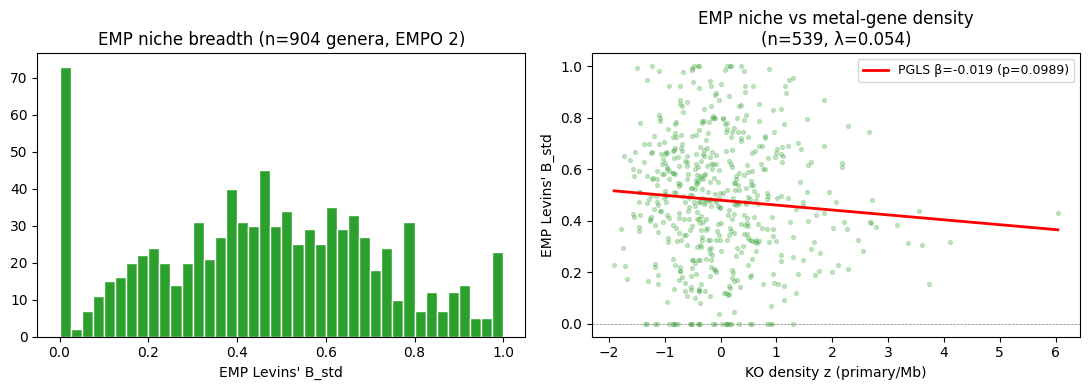

Saved: figures/08_emp_levins_vs_ko_density.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

_resp_col = 'emp_levins_B_std_resp' if 'emp_levins_B_std_resp' in emp_merged.columns else 'emp_levins_B_std'

axes[0].hist(levins['emp_levins_B_std'], bins=40, color='#2ca02c', edgecolor='white')
axes[0].set_xlabel("EMP Levins' B_std")
axes[0].set_title(f'EMP niche breadth (n={len(levins):,} genera, EMPO {_EMPO_LEVEL})')

axes[1].scatter(emp_merged['predictor_z'], emp_merged[_resp_col],
                alpha=0.25, s=8, color='#2ca02c')
if res_emp.get('converged', False):
    _xr = np.linspace(emp_merged['predictor_z'].min(), emp_merged['predictor_z'].max(), 100)
    _b  = res_emp['beta']
    _ic = emp_merged[_resp_col].mean() - _b * emp_merged['predictor_z'].mean()
    axes[1].plot(_xr, _ic + _b * _xr, 'r-', lw=2,
                  label=f"PGLS β={_b:+.3f} (p={res_emp['p_value']:.3g})")
axes[1].set_xlabel('KO density z (primary/Mb)')
axes[1].set_ylabel("EMP Levins' B_std")
axes[1].set_title(f'EMP niche vs metal-gene density\n(n={res_emp.get("n","?")}, '
                    f'λ={res_emp.get("lambda_est", float("nan")):.3f})')
axes[1].legend(fontsize=9)
axes[1].axhline(0, color='gray', lw=0.5, ls='--')

plt.tight_layout()
fig.savefig(FIGS / '08_emp_levins_vs_ko_density.png', dpi=150)
plt.show()
print('Saved: figures/08_emp_levins_vs_ko_density.png')


## Block 7 — Reporting summary

Copy values into INTERPRETATION_TABLE.md §7.


In [20]:
_fallback_note = f'EMPO level {_EMPO_LEVEL} used' + (' (fallback from empo_3)' if _FALLBACK else '')

print('=== NB08 REPORTING SUMMARY ===')
print(f'Niche metric  : EMP Levins B_std, EMPO_{_EMPO_LEVEL} ({_n_empo_cats} categories)')
print(f'Predictor     : ko_per_mb_primary (Tier 1+2, 140 KOs, kbase.ke_pangenome)')
print(f'n genera      : {res_emp.get("n")}')
print(f'β             = {res_emp.get("beta", float("nan")):.5f}')
print(f'SE            = {res_emp.get("se",   float("nan")):.5f}')
print(f't             = {res_emp.get("t_stat", float("nan")):.3f}')
print(f'p             = {res_emp.get("p_value", float("nan")):.3e}')
print(f'λ             = {res_emp.get("lambda_est", float("nan")):.3f}')
print(f'r²            = {res_emp.get("r2", float("nan")):.4f}')
print(f'Direction     : {_direction}')
print(f'Note          : {_fallback_note}. Run once; no iterative tuning.')
print()
print('Add to INTERPRETATION_TABLE.md §7 (Exploratory Findings):')
print(f'| EMP 16S niche breadth PGLS | NB08 | nb080012 | '
      f'EMP-derived Levins B_std ({_n_empo_cats} EMPO_{_EMPO_LEVEL} cats) ~ '
      f'ko_per_mb_primary: β={res_emp.get("beta", float("nan")):.4f}, '
      f'p={res_emp.get("p_value", float("nan")):.3e}, '
      f'n={res_emp.get("n")}, λ={res_emp.get("lambda_est", float("nan")):.3f}. '
      f'{_direction}. {_fallback_note}. '
      f'| Moderate — independent 16S dataset with EMP breadth | '
      f'Report in thesis as independent validation attempt. |')


=== NB08 REPORTING SUMMARY ===
Niche metric  : EMP Levins B_std, EMPO_2 (6 categories)
Predictor     : ko_per_mb_primary (Tier 1+2, 140 KOs, kbase.ke_pangenome)
n genera      : 539
β             = -0.01901
SE            = nan
t             = -1.653
p             = 9.889e-02
λ             = 0.054
r²            = 0.1977
Direction     : Directionally consistent with P1 (β < 0), non-significant
Note          : EMPO level 2 used (fallback from empo_3). Run once; no iterative tuning.

Add to INTERPRETATION_TABLE.md §7 (Exploratory Findings):
| EMP 16S niche breadth PGLS | NB08 | nb080012 | EMP-derived Levins B_std (6 EMPO_2 cats) ~ ko_per_mb_primary: β=-0.0190, p=9.889e-02, n=539, λ=0.054. Directionally consistent with P1 (β < 0), non-significant. EMPO level 2 used (fallback from empo_3). | Moderate — independent 16S dataset with EMP breadth | Report in thesis as independent validation attempt. |
